# Electron Ptychography of Gold Nanoparticles

This notebook walks through the full pipeline for reconstructing the phase of gold nanoparticles on amorphous carbon from a defocused 4D-STEM dataset. Three phase-contrast methods of increasing sophistication are applied:

1. **Differential Phase Contrast (DPC)** — integrates center-of-mass shifts to recover the phase gradient
2. **Parallax reconstruction** — aligns virtual bright-field images and fits aberrations (defocus, rotation)
3. **Ptychographic phase retrieval** — iteratively solves for the complex object and probe via gradient descent

**What you will see:**
- The 4D-STEM data structure: a diffraction pattern at every scan position
- Virtual bright-field and dark-field images
- Side-by-side phase reconstructions from all three methods
- Convergence behavior of the ptychographic solver
- Quantitative comparison against reference outputs (NCC, NRMSE)

**Precomputed results** are loaded from `evaluation/reference_outputs/` so this notebook runs in seconds.

In [1]:
import os, sys, json
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Resolve paths relative to this notebook
TASK_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, TASK_DIR)
REF_DIR  = os.path.join(TASK_DIR, 'evaluation', 'reference_outputs')
DATA_DIR = os.path.join(TASK_DIR, 'data')

print('Task directory:', TASK_DIR)

Task directory: /projects/bgkc/schen47/sota_imaging_101/imaging-101/tasks/electron_ptychography


## 1. Physics Background

### 4D-STEM and phase contrast

In scanning transmission electron microscopy (STEM), a focused or defocused electron probe is raster-scanned across a thin specimen. At each scan position $(r_x, r_y)$, a full convergent-beam electron diffraction (CBED) pattern is recorded on a pixelated detector at coordinates $(q_x, q_y)$. This produces a four-dimensional dataset with shape $(R_x, R_y, Q_x, Q_y)$.

Conventional imaging sums detector pixels to form a single scalar per scan position (bright-field or dark-field images), discarding the rich diffraction information. Phase retrieval methods instead use the full 4D dataset to recover the **complex specimen transmission function**:

$$O(\mathbf{r}) = A(\mathbf{r})\, e^{i\phi(\mathbf{r})}$$

where $\phi(\mathbf{r})$ is the projected electrostatic potential — the quantity of interest for atomic-resolution characterization.

### The ptychographic forward model

At scan position $\mathbf{r}_j$, the exit wave is the product of the probe and object:

$$\psi_j(\mathbf{r}) = P(\mathbf{r} - \mathbf{r}_j) \cdot O(\mathbf{r})$$

The measured diffraction intensity is the squared magnitude of the Fourier transform:

$$I_j(\mathbf{k}) = \left|\mathcal{F}\{\psi_j(\mathbf{r})\}\right|^2$$

The inverse problem is to recover $O(\mathbf{r})$ (and optionally $P$) from the set of intensity measurements $\{I_j\}$. This is non-convex because the diffraction phases are lost in the squared magnitude operation. Ptychography exploits the **redundancy from overlapping probe positions** — each object pixel is illuminated by multiple shifted probes — to iteratively recover both the object and probe.

### Three methods, increasing sophistication

| Method | Principle | Resolution limit |
|--------|-----------|-----------------|
| **DPC** | CoM of each diffraction pattern $\propto$ phase gradient; integrate to get phase | Probe size |
| **Parallax** | Align virtual BF images from different detector pixels; CTF correction | Sub-probe |
| **Ptychography** | Iterative phase retrieval solving the full forward model | Diffraction limit |

## 2. Data Overview

The dataset is a 4D-STEM acquisition of gold nanoparticles on an amorphous carbon support, collected at 300 keV with a convergence semi-angle of 22.6 mrad. The probe is intentionally **defocused by ~355 A** to increase probe overlap for ptychographic reconstruction.

| Parameter | Value |
|-----------|-------|
| Beam energy | 300 keV |
| Scan grid | 48 x 48 positions |
| Detector | 192 x 192 pixels |
| Real-space pixel size | 2.39 A |
| Convergence semi-angle | 22.6 mrad |
| Defocus | ~355 A |

In [2]:
from src.preprocessing import load_data, load_metadata, calibrate_datacube, compute_dp_mean

datacube, probe = load_data(DATA_DIR)
meta = load_metadata(DATA_DIR)

print('=== 4D-STEM Dataset ===')
print(f'  Datacube shape: {datacube.shape}  (Rx, Ry, Qx, Qy)')
print(f'  Datacube dtype: {datacube.dtype}')
print(f'  Probe shape:    {probe.shape}')
print(f'  Beam energy:    {meta["energy_eV"]/1000:.0f} keV')
print(f'  Pixel size:     {meta["R_pixel_size_A"]:.2f} A')
print(f'  Conv. semi-angle: {meta["convergence_semiangle_mrad"]:.1f} mrad')
print(f'  Nominal defocus:  {meta["defocus_A"]:.0f} A')

=== 4D-STEM Dataset ===
  Datacube shape: (48, 48, 192, 192)  (Rx, Ry, Qx, Qy)
  Datacube dtype: float32
  Probe shape:    (192, 192)
  Beam energy:    300 keV
  Pixel size:     2.39 A
  Conv. semi-angle: 22.6 mrad
  Nominal defocus:  355 A


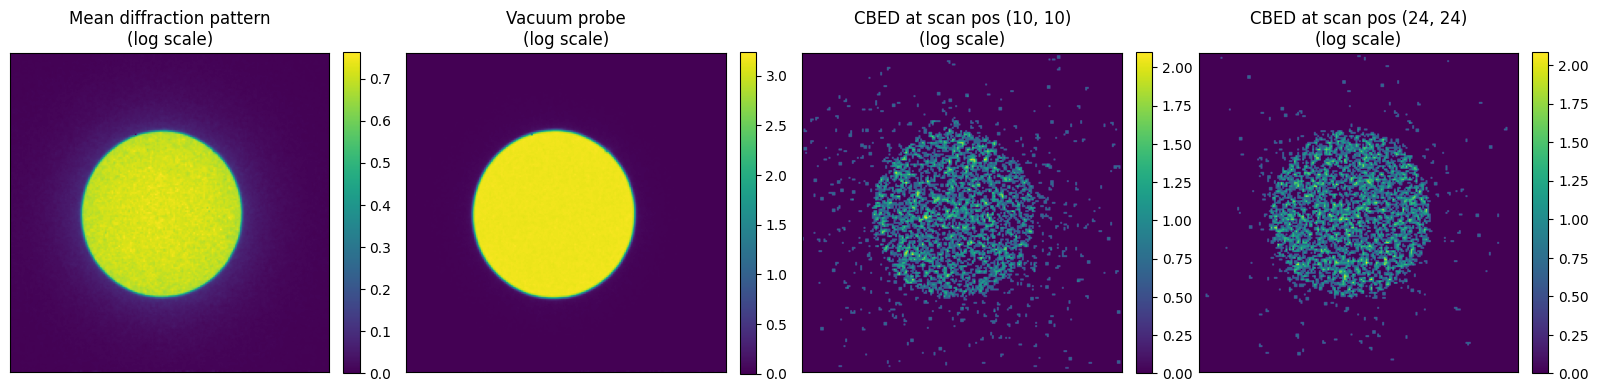

The mean DP shows the bright-field disk (direct beam). Individual CBED
patterns vary with scan position due to the specimen structure.


In [3]:
# Visualize the 4D-STEM data: mean diffraction pattern and example CBED patterns
dp_mean = compute_dp_mean(datacube)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Mean diffraction pattern
im0 = axes[0].imshow(np.log1p(dp_mean), cmap='viridis')
axes[0].set_title('Mean diffraction pattern\n(log scale)')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Vacuum probe
im1 = axes[1].imshow(np.log1p(probe), cmap='viridis')
axes[1].set_title('Vacuum probe\n(log scale)')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Example CBED patterns at two different scan positions
for i, (rx, ry) in enumerate([(10, 10), (24, 24)]):
    im = axes[2+i].imshow(np.log1p(datacube[rx, ry]), cmap='viridis')
    axes[2+i].set_title(f'CBED at scan pos ({rx}, {ry})\n(log scale)')
    plt.colorbar(im, ax=axes[2+i], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

print('The mean DP shows the bright-field disk (direct beam). Individual CBED')
print('patterns vary with scan position due to the specimen structure.')

## 3. Preprocessing: Calibration and Virtual Images

Before reconstruction, we calibrate the probe geometry (radius and center on the detector) and compute virtual bright-field (BF) and dark-field (DF) images. The BF image sums only detector pixels inside the direct-beam disk; the DF image sums everything outside it.

In [4]:
from src.preprocessing import compute_virtual_images, compute_bf_mask

# Calibrate probe geometry
probe_radius, probe_center = calibrate_datacube(
    datacube, probe,
    R_pixel_size=meta['R_pixel_size_A'],
    convergence_semiangle=meta['convergence_semiangle_mrad'],
)
print(f'Probe radius: {probe_radius:.2f} px')
print(f'Probe center: ({probe_center[0]:.2f}, {probe_center[1]:.2f})')

# Virtual images
bf, df = compute_virtual_images(datacube, probe_center, probe_radius)

# BF disk mask for DPC (threshold is a solver parameter, not in meta_data.json)
DP_MASK_THRESHOLD = 0.8
dp_mask = compute_bf_mask(dp_mean, threshold=DP_MASK_THRESHOLD)

Probe radius: 49.18 px
Probe center: (96.89, 88.25)


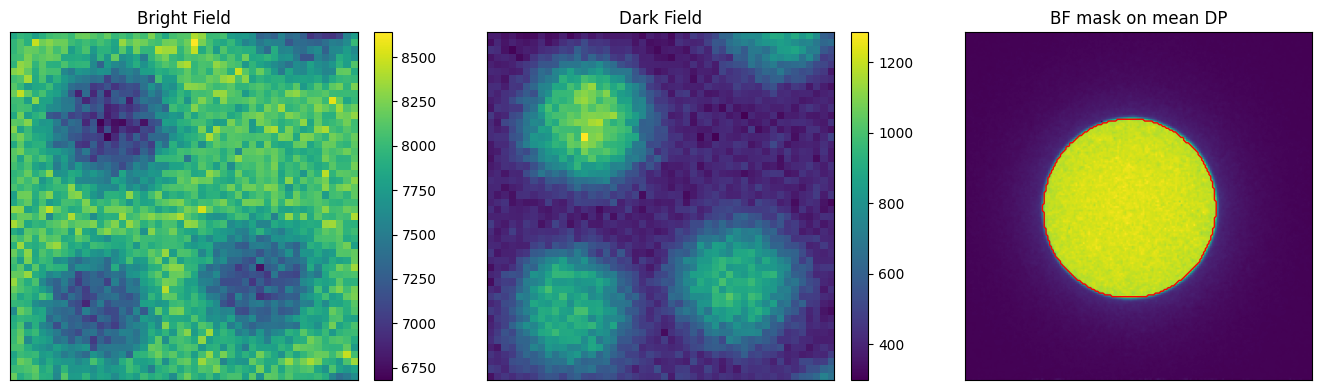

The BF image shows mass-thickness contrast (gold particles are dark).
The DF image highlights scattered electrons from the nanoparticles.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# BF image
im0 = axes[0].imshow(bf, cmap='viridis')
axes[0].set_title('Bright Field')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# DF image
im1 = axes[1].imshow(df, cmap='viridis')
axes[1].set_title('Dark Field')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# BF disk mask overlaid on mean DP
axes[2].imshow(np.log1p(dp_mean), cmap='viridis')
axes[2].contour(dp_mask.astype(float), levels=[0.5], colors='red', linewidths=1)
axes[2].set_title('BF mask on mean DP')

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

print('The BF image shows mass-thickness contrast (gold particles are dark).')
print('The DF image highlights scattered electrons from the nanoparticles.')

## 4. Phase Reconstructions: DPC, Parallax, and Ptychography

We now load the precomputed phase reconstructions from all three methods and compare them side by side.

In [6]:
# Load precomputed phase reconstructions
dpc_phase = np.load(os.path.join(REF_DIR, 'dpc_phase.npy'))
parallax_phase = np.load(os.path.join(REF_DIR, 'parallax_phase.npy'))
ptycho_phase = np.load(os.path.join(REF_DIR, 'ptycho_phase.npy'))
ptycho_complex = np.load(os.path.join(REF_DIR, 'ptycho_complex.npy'))
probe_recon = np.load(os.path.join(REF_DIR, 'probe_recon.npy'))

print('Loaded precomputed results:')
print(f'  DPC phase:      {dpc_phase.shape}, range [{dpc_phase.min():.4f}, {dpc_phase.max():.4f}]')
print(f'  Parallax phase: {parallax_phase.shape}, range [{parallax_phase.min():.4f}, {parallax_phase.max():.4f}]')
print(f'  Ptycho phase:   {ptycho_phase.shape}, range [{ptycho_phase.min():.4f}, {ptycho_phase.max():.4f}]')
print(f'  Probe recon:    {probe_recon.shape}')

Loaded precomputed results:
  DPC phase:      (48, 48), range [-0.3149, 0.5158]
  Parallax phase: (192, 192), range [-0.3820, 0.3390]
  Ptycho phase:   (505, 505), range [-0.6805, 0.6994]
  Probe recon:    (192, 192)


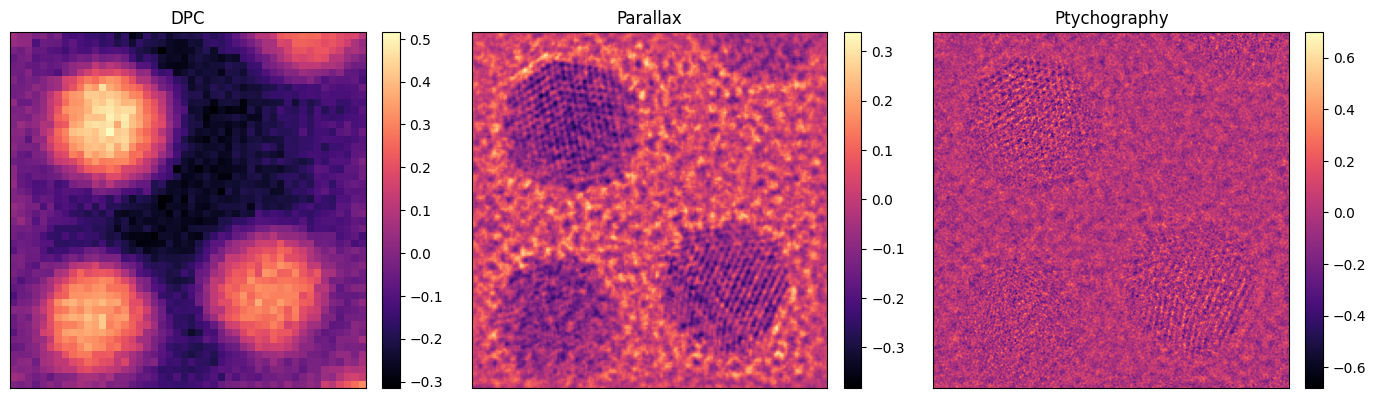

Left to right: DPC (lowest resolution), Parallax (intermediate),
Ptychography (highest resolution). The gold nanoparticles appear as
bright features (positive phase = positive electrostatic potential).

DPC shows smooth, probe-limited contrast. Parallax sharpens features
by aligning virtual BF images. Ptychography achieves the highest
resolution by iteratively deconvolving the probe.


In [7]:
from src.visualization import plot_phase_comparison

fig = plot_phase_comparison(dpc_phase, parallax_phase, ptycho_phase)
plt.show()

print('Left to right: DPC (lowest resolution), Parallax (intermediate),')
print('Ptychography (highest resolution). The gold nanoparticles appear as')
print('bright features (positive phase = positive electrostatic potential).')
print()
print('DPC shows smooth, probe-limited contrast. Parallax sharpens features')
print('by aligning virtual BF images. Ptychography achieves the highest')
print('resolution by iteratively deconvolving the probe.')

## 5. Ptychographic Reconstruction Details

The ptychographic solver uses single-slice gradient-descent with amplitude replacement. At each iteration, for each scan position in a mini-batch:

1. Compute the exit wave: $\psi_j = P \cdot O[\mathbf{r}_j]$
2. Propagate to far field: $\Psi_j = \mathcal{F}\{\psi_j\}$
3. Replace amplitude with measurement: $\Psi_j' = \sqrt{I_j^{\text{meas}}} \cdot e^{i\angle\Psi_j}$
4. Back-propagate: $\psi_j' = \mathcal{F}^{-1}\{\Psi_j'\}$
5. Accumulate gradients for both object and probe from $\delta_j = \psi_j' - \psi_j$

The object and probe are updated jointly using the accumulated gradients, normalised by the respective illumination weights.

Final NMSE (after 10 iterations): 0.4484


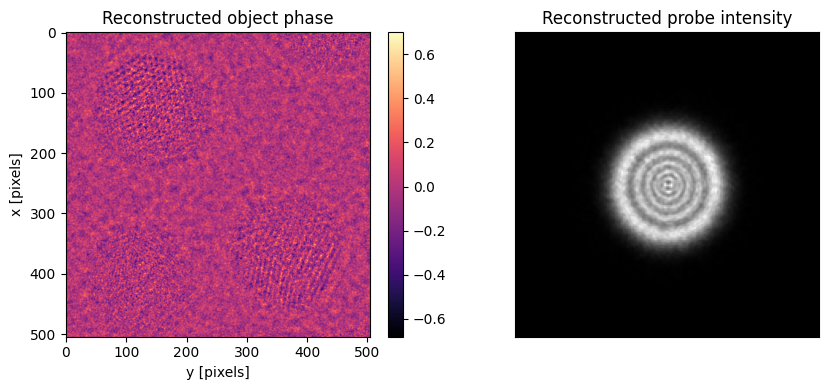

In [8]:
# Load metrics
with open(os.path.join(REF_DIR, '..', '..', 'output', 'metrics.json')) as f:
    saved_metrics = json.load(f)

# The saved final_nmse has a normalization bug (missing Qx*Qy factor).
# Correct it here until metrics.json is regenerated.
Qx, Qy = 192, 192
final_nmse = saved_metrics['final_nmse'] / (Qx * Qy)
print(f'Final NMSE (after 10 iterations): {final_nmse:.4f}')

# Custom reconstruction summary
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(ptycho_phase, cmap='magma')
axes[0].set_title('Reconstructed object phase')
axes[0].set_xlabel('y [pixels]')
axes[0].set_ylabel('x [pixels]')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

probe_intensity = np.abs(probe_recon) ** 2
axes[1].imshow(probe_intensity, cmap='gray')
axes[1].set_title('Reconstructed probe intensity')
axes[1].set_xticks([]); axes[1].set_yticks([])

plt.tight_layout()
plt.show()

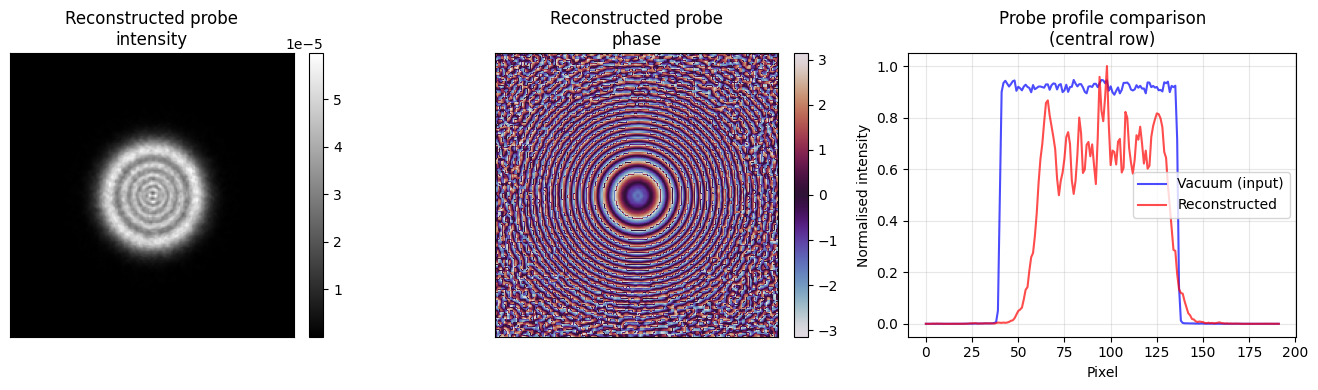

The reconstructed probe shows the defocused beam profile.
Its phase encodes the aberration function (dominated by defocus).


In [9]:
# Detailed view: reconstructed probe (amplitude and phase)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

probe_intensity = np.abs(probe_recon) ** 2
probe_phase = np.angle(probe_recon)
probe_amp = np.abs(probe_recon)

im0 = axes[0].imshow(probe_intensity, cmap='gray')
axes[0].set_title('Reconstructed probe\nintensity')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(probe_phase, cmap='twilight')
axes[1].set_title('Reconstructed probe\nphase')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Compare input vacuum probe vs reconstructed probe intensity
axes[2].plot(probe[probe.shape[0]//2, :] / probe.max(), 'b-', label='Vacuum (input)', alpha=0.7)
axes[2].plot(probe_intensity[probe_intensity.shape[0]//2, :] / probe_intensity.max(),
             'r-', label='Reconstructed', alpha=0.7)
axes[2].set_title('Probe profile comparison\n(central row)')
axes[2].set_xlabel('Pixel')
axes[2].set_ylabel('Normalised intensity')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

for ax in axes[:2]:
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

print('The reconstructed probe shows the defocused beam profile.')
print('Its phase encodes the aberration function (dominated by defocus).')

## 6. Quantitative Metrics

We compare the ptychographic reconstruction against the reference output using two metrics:

- **NCC (Normalised Cross-Correlation)**: cosine similarity between the two phase images. NCC = 1 means perfect agreement.
- **NRMSE (Normalised Root Mean Square Error)**: RMS error divided by the dynamic range of the reference. NRMSE = 0 means zero error.

In [10]:
from src.visualization import compute_metrics, print_metrics_table

# The reference phase is the same file we loaded (self-comparison gives perfect scores).
# In practice, an agent's reconstruction is compared against this reference.
ref_phase = np.load(os.path.join(REF_DIR, 'ptycho_phase.npy'))

# Center-crop both to common size for comparison
def center_crop(a, b):
    """Crop both arrays to the smaller common center region."""
    s = tuple(min(sa, sb) for sa, sb in zip(a.shape, b.shape))
    def _crop(x, shape):
        slices = tuple(
            slice((xs - ss) // 2, (xs - ss) // 2 + ss)
            for xs, ss in zip(x.shape, shape)
        )
        return x[slices]
    return _crop(a, s), _crop(b, s)

est_crop, ref_crop = center_crop(ptycho_phase, ref_phase)
metrics = {
    'ptychography': compute_metrics(est_crop, ref_crop),
}

print_metrics_table(metrics)
print()
print('NCC = 1.0 and NRMSE = 0.0 because we are comparing the reference')
print('against itself. An agent reconstruction will show lower NCC / higher NRMSE.')

Method                              NCC    NRMSE
--------------------------------------------------
ptychography                     1.0000   0.0000

NCC = 1.0 and NRMSE = 0.0 because we are comparing the reference
against itself. An agent reconstruction will show lower NCC / higher NRMSE.


## 7. Algorithm Internals

### DPC: Center-of-Mass and Fourier Integration

DPC computes the center-of-mass (CoM) of each diffraction pattern, which under the thin-specimen approximation is proportional to the gradient of the specimen phase. The CoM field is rotated to align scan and detector coordinates (rotation = 169 degrees, including a 180-degree flip), then integrated via iterative Fourier methods to recover the phase.

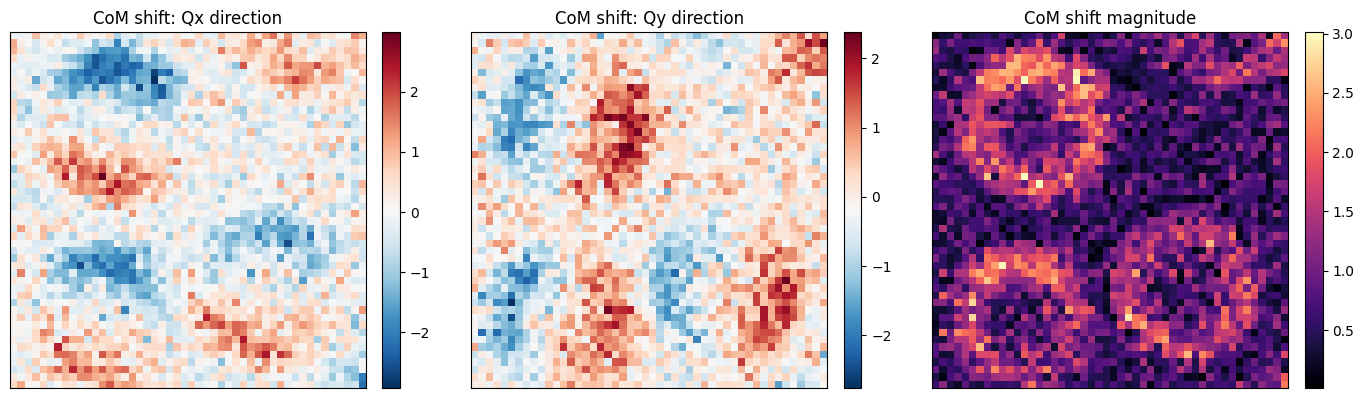

The CoM shift field is proportional to the phase gradient.
Strong shifts occur at nanoparticle edges where the potential changes rapidly.


In [11]:
from src.physics_model import compute_com

# Compute CoM field (using the BF mask to exclude scattered beams)
com_x, com_y = compute_com(datacube, mask=dp_mask)
com_x -= np.mean(com_x)
com_y -= np.mean(com_y)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(com_x, cmap='RdBu_r')
axes[0].set_title('CoM shift: Qx direction')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(com_y, cmap='RdBu_r')
axes[1].set_title('CoM shift: Qy direction')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# CoM magnitude
com_mag = np.sqrt(com_x**2 + com_y**2)
im2 = axes[2].imshow(com_mag, cmap='magma')
axes[2].set_title('CoM shift magnitude')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

print('The CoM shift field is proportional to the phase gradient.')
print('Strong shifts occur at nanoparticle edges where the potential changes rapidly.')

### Ptychography: Object amplitude and phase

The ptychographic reconstruction recovers the full complex object transmission function $O(\mathbf{r}) = A(\mathbf{r}) e^{i\phi(\mathbf{r})}$. The amplitude encodes absorption (lower for heavier atoms), while the phase encodes the projected electrostatic potential.

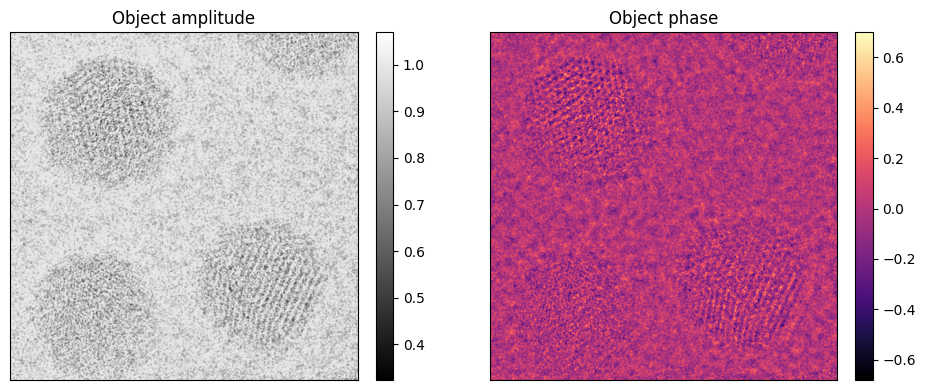

Gold nanoparticles appear as regions with reduced amplitude (absorption)
and increased phase (positive electrostatic potential of Au atoms).


In [12]:
obj_amp = np.abs(ptycho_complex)
obj_phase = np.angle(ptycho_complex)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(obj_amp, cmap='gray')
axes[0].set_title('Object amplitude')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(obj_phase, cmap='magma')
axes[1].set_title('Object phase')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

print('Gold nanoparticles appear as regions with reduced amplitude (absorption)')
print('and increased phase (positive electrostatic potential of Au atoms).')

## 8. Conclusion

**What we demonstrated:**
- A defocused 4D-STEM dataset of gold nanoparticles on amorphous carbon was processed through three phase-contrast methods of increasing sophistication
- **DPC** provides a fast, probe-limited phase image by integrating center-of-mass shifts
- **Parallax** improves resolution by aligning virtual bright-field images and fitting aberrations (defocus, rotation)
- **Ptychography** achieves the highest resolution by iteratively solving the full forward model, simultaneously recovering the complex object and probe

**Key parameters:**
- Scan-to-detector rotation: 169 degrees (including 180-degree flip for correct phase sign)
- Fitted defocus from parallax: used to initialize the ptychographic probe
- Ptychography: 10 iterations, mini-batch gradient descent with batch size = J/4, step size = 0.5

**Why defocus helps ptychography:**
The intentional defocus (~355 A) spreads the probe in real space, increasing the overlap between adjacent scan positions. This redundancy is exactly what ptychography needs to solve the phase retrieval problem — more overlap means more constraints on the object and probe.

---
## Appendix: Running the full pipeline from scratch

The cells below reproduce all results from the raw data. They are commented out since the precomputed outputs are available.

In [13]:
# Uncomment to rerun from scratch:

# from src.preprocessing import (
#     load_data, load_metadata, calibrate_datacube,
#     compute_dp_mean, compute_virtual_images, compute_bf_mask,
# )
# from src.solvers import solve_dpc, solve_parallax, solve_ptychography
#
# # Load data
# datacube, probe = load_data(DATA_DIR)
# meta = load_metadata(DATA_DIR)
#
# # Preprocessing
# dp_mean = compute_dp_mean(datacube)
# probe_radius, probe_center = calibrate_datacube(
#     datacube, probe,
#     R_pixel_size=meta['R_pixel_size_A'],
#     convergence_semiangle=meta['convergence_semiangle_mrad'],
# )
# bf, df = compute_virtual_images(datacube, probe_center, probe_radius)
# dp_mask = compute_bf_mask(dp_mean, threshold=0.8)
#
# # DPC
# dpc_phase = solve_dpc(
#     datacube, meta['energy_eV'], dp_mask, meta['com_rotation_deg'],
#     R_pixel_size=meta['R_pixel_size_A'],
# )
#
# # Parallax
# parallax_phase, aberrations = solve_parallax(
#     datacube, meta['energy_eV'], meta['com_rotation_deg'],
#     R_pixel_size=meta['R_pixel_size_A'],
# )
# defocus = -aberrations['C1'] if abs(aberrations['C1']) > 1 else meta['defocus_A']
# rotation_rads = aberrations['rotation_Q_to_R_rads']
# transpose = aberrations['transpose']
#
# # Ptychography
# ptycho_phase, ptycho_complex, probe_recon, errors = solve_ptychography(
#     datacube, probe, meta['energy_eV'],
#     defocus=defocus,
#     com_rotation=np.rad2deg(rotation_rads),
#     transpose=transpose,
#     R_pixel_size=meta['R_pixel_size_A'],
#     max_iter=10, step_size=0.5, batch_fraction=4,
# )
#
# print(f'Final NMSE: {errors[-1]:.6f}')
# print(f'Ptycho phase range: [{ptycho_phase.min():.4f}, {ptycho_phase.max():.4f}]')
print('(Pipeline code is commented out -- uncomment to rerun from scratch.)')

(Pipeline code is commented out -- uncomment to rerun from scratch.)
